![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:** Nacho
**Dataset:** Inside Airbnb — Barcelona, snapshot 2026-06-24

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [2]:
import sqlite3

con = sqlite3.connect("../data/project.db")

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

### Context

In Barcelona, renting a home to tourists for stays **under 31 days** requires a tourist-use licence (a *HUTB* number), which Airbnb listings are expected to display. Stays of **31 days or more** count as seasonal rentals and fall outside that regime. This project asks how Barcelona's Airbnb market looks against those rules.

### Definitions

- **Short-stay listing:** minimum stay under 31 nights.
- **Mid-term listing:** minimum stay of 31 nights or more.
- **Active listing:** at least one review in the 12 months before the snapshot (24 June 2025 – 24 June 2026).
- **Prices** are nightly, in EUR.

### Q1: Licence compliance

**What share of Barcelona's short-stay listings shows no verifiable tourist licence, and where is it concentrated?**

- **Hypothesis:** unlicensed listings are concentrated in private rooms and in outer districts rather than the tourist centre, and most of them are inactive.
- **Who cares:** the city council's inspection team, deciding where to focus inspections; if most unlicensed listings are inactive, the real enforcement problem is smaller than the headline count.

### Q2: The mid-term segment

**How large is the mid-term (31+ nights) segment, and how does it compare with licensed short-stay listings on location, price per guest and activity?**

- **Hypothesis:** the segment sits in the same central districts as licensed short stays, is cheaper per guest and less active, suggesting it partly absorbs supply that cannot get a tourist licence rather than being a separate product.
- **Who cares:** housing policy makers, deciding whether seasonal rentals need their own rules; owners choosing between the two rental models.

### How the analysis answers them

| Query | Question it answers | Research question |
|---|---|---|
| 1 | What share of short-stay listings shows each licence status? | Q1 |
| 2 | In which districts is the unlicensed share highest? | Q1 |
| 3 | Which room types are unlicensed? | Q1 |
| 4 | Are unlicensed listings actually active? | Q1 |
| 5 | Do licensed listings use a number of their own? | Q1 |
| 6 | How big is the mid-term segment, and how is its minimum stay set? | Q2 |
| 7 | Is it in the same districts as licensed short stays? | Q2 |
| 8 | How does it compare on price per guest and activity? | Q2 |

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

### Source

[Inside Airbnb](http://insideairbnb.com) publishes quarterly snapshots of every Airbnb listing in a city. This project uses the **Barcelona snapshot of 24 June 2026**: 15,293 listings and about 1 million reviews, downloaded with `download_data.py`.

- **One listing** is one Airbnb advert as it appeared on the snapshot date: its location, host, room type, price, minimum stay and licence field.
- **One review** is one guest review left on a listing, with its date.

### Database

![ERD](../Images/erd.png)

| Table | Rows | What one row is |
|---|---|---|
| `districts` | 10 | A Barcelona district |
| `neighbourhoods` | 69 | A neighbourhood, inside one district |
| `hosts` | 4,595 | An Airbnb host |
| `licence_status` | 5 | A licence category, derived from the raw licence text |
| `listings` | 15,293 | An Airbnb listing |
| `reviews` | 1,026,931 | A review left on a listing |

### Cleaning decisions that affect the results

- **Licence status** was parsed from a free-text field into 5 categories. Licence numbers were normalised (`HUTB0124070` and `HUTB-012407` count as the same licence).
- **Price** was stored as text with a `$` sign but is in EUR. It is missing for 12.7% of listings, mostly adverts not live on the snapshot date; those are excluded from price comparisons, not filled in.
- **6,592 reviews** (0.6%) pointed to listings no longer in the snapshot and were removed.
- **Review scores** are missing exactly for never-reviewed listings, and were kept as missing.

Full details in `01_eda.ipynb` and `02_processing.ipynb`.

In [3]:
tables = ["districts", "neighbourhoods", "hosts", "licence_status", "listings", "reviews"]

for table in tables:
    n_rows = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table:15} {n_rows:>9,} rows")

districts              10 rows
neighbourhoods         69 rows
hosts               4,595 rows
licence_status          5 rows
listings           15,293 rows
reviews         1,026,931 rows


---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

In [4]:
from pathlib import Path

sql_text = Path("../sql/queries.sql").read_text()

queries = {}
for block in sql_text.split("-- @query:")[1:]:
    name, sql = block.split("\n", 1)
    queries[name.strip()] = sql

print(list(queries.keys()))

['q1', 'q2', 'q3', 'q4', 'q5a', 'q5b', 'q6a', 'q6b', 'q7', 'q8a', 'q8b']


### Q1: Licence compliance

#### Query 1: What share of short-stay listings shows each licence status?

In [5]:
pd.read_sql(queries["q1"], con)

,status_code,n_listings,pct_listings
0,hutb_licence,7336,75.1
1,missing,1435,14.7
2,exempt_other,718,7.4
3,other_code,276,2.8


Three in four short-stay listings (75.1%) show a HUTB licence, and **14.7% (1,435) show no licence at all**. This is the headline figure the rest of Q1 breaks down.

#### Query 2: In which districts is the unlicensed share highest?

In [6]:
pd.read_sql(queries["q2"], con)

,district_name,n_short_stay,n_no_licence,pct_no_licence
0,Nou Barris,106,29,27.4
1,Horta-Guinardó,201,54,26.9
2,Sant Andreu,123,33,26.8
3,Ciutat Vella,1627,349,21.5
4,Sant Martí,951,175,18.4
5,Les Corts,209,34,16.3
6,Gràcia,879,127,14.4
7,Sarrià-Sant Gervasi,435,62,14.3
8,Sants-Montjuïc,1009,131,13.0
9,Eixample,4225,441,10.4


The highest shares are in outer districts (Nou Barris, Horta-Guinardó, Sant Andreu, about 27%), but **the most unlicensed listings are in the centre**: Eixample (441) and Ciutat Vella (349) together hold more than half.

#### Query 3: Which room types are unlicensed?

In [7]:
pd.read_sql(queries["q3"], con)

,room_type,n_short_stay,n_no_licence,pct_no_licence,pct_of_all_unlicensed
0,Private room,2458,1140,46.4,79.4
1,Entire home/apt,7132,290,4.1,20.2
2,Shared room,107,5,4.7,0.3
3,Hotel room,68,0,0.0,0.0


**Private rooms are 46.4% unlicensed, against 4.1% of entire homes**, and they account for 79.4% of all unlicensed listings. The likely reason is that the HUTB licence covers entire homes, not rooms.

#### Query 4: Are unlicensed listings actually active?

In [8]:
pd.read_sql(queries["q4"], con)

,status_code,n_short_stay,n_active,pct_active
0,hutb_licence,7336,6149,83.8
1,exempt_other,718,560,78.0
2,other_code,276,136,49.3
3,missing,1435,367,25.6


**Only 25.6% of unlicensed listings were active in the last year**, against 83.8% of licensed ones. The 367 active unlicensed listings are about 5% of active short-stay supply, a third of what the headline figure suggests.

#### Query 5: Do licensed listings use a number of their own?

In [9]:
pd.read_sql(queries["q5a"], con)

,licence_number,n_listings,n_hosts
0,HUTB-000000,35,15
1,HUTB-012407,30,1
2,HUTB-012457,29,1
3,HUTB-246789,26,12
4,HUTB-007110,24,2
5,HUTB-639071,15,2
6,HUTB-076008,14,2
7,HUTB-004463,12,8
8,HUTB-000219,12,1
9,HUTB-123456,11,11


In [10]:
pd.read_sql(queries["q5b"], con)

,n_shared_numbers,n_listings_on_shared,n_numbers_multi_host,n_listings_multi_host
0,581,1743,410,1250


**23.5% of listings showing a HUTB number share it with another listing**, and some numbers are clearly invented (`HUTB-000000`, `HUTB-123456`). The 75.1% "licensed" figure from Query 1 is therefore an upper bound.

### Q2: The mid-term segment

#### Query 6: How big is the mid-term segment, and how is its minimum stay set?

In [11]:
pd.read_sql(queries["q6a"], con)

,segment,n_listings,pct_listings
0,short_stay,9765,63.9
1,mid_term,5527,36.1
2,unknown,1,0.0


In [12]:
pd.read_sql(queries["q6b"], con)

,min_stay_band,n_listings,pct_of_mid_term
0,31 nights,2644,47.8
1,32 nights,2647,47.9
2,33-90 nights,193,3.5
3,91+ nights,43,0.8


**36.1% of all listings require 31+ nights, and 95.7% of those set the minimum at exactly 31 or 32**, just above the licence threshold, rather than targeting genuinely long stays.

#### Query 7: Is the segment in the same districts as licensed short stays?

In [13]:
pd.read_sql(queries["q7"], con)

,district_name,n_listings,n_mid_term,pct_mid_term_in_district,pct_of_all_mid_term,pct_of_all_licensed_short
0,Ciutat Vella,3247,1620,49.9,29.3,14.3
1,Eixample,5835,1609,27.6,29.1,45.4
2,Gràcia,1366,487,35.7,8.8,9.4
3,Sant Martí,1436,485,33.8,8.8,9.5
4,Sarrià-Sant Gervasi,888,453,51.0,8.2,4.2
5,Sants-Montjuïc,1448,439,30.3,7.9,11.0
6,Horta-Guinardó,358,157,43.9,2.8,1.9
7,Les Corts,327,118,36.1,2.1,2.2
8,Sant Andreu,225,102,45.3,1.8,1.1
9,Nou Barris,163,57,35.0,1.0,1.0


Yes overall: **Ciutat Vella and Eixample hold 58.4% of mid-term listings and 59.7% of licensed short stays**. But in Ciutat Vella half of all listings are mid-term, while Eixample remains mainly licensed short-stay.

#### Query 8: How does it compare on price per guest and activity?

In [14]:
pd.read_sql(queries["q8a"], con)

,segment,n_listings,n_with_price,avg_guests,avg_price_per_guest,avg_nights_booked,pct_active,avg_rating
0,licensed_short_stay,7336,7096,4.7,73.9,117.0,83.8,4.64
1,mid_term,5527,4843,2.9,35.7,64.0,44.6,4.58


In [15]:
pd.read_sql(queries["q8b"], con)

,price_per_guest_band,n_licensed_short_stay,n_mid_term
0,under 30,171,2154
1,30 to 60,2732,2380
2,60 or more,4193,309


In [16]:
# Cross-check: SQLite has no MEDIAN(), so compute the median in pandas
check = pd.read_sql("""
    SELECT CASE WHEN l.minimum_nights >= 31 THEN 'mid_term'
                ELSE 'licensed_short_stay' END AS segment,
           l.price_eur / l.accommodates AS price_per_guest
    FROM listings AS l
    JOIN licence_status AS ls ON l.licence_status_id = ls.licence_status_id
    WHERE (l.minimum_nights >= 31
           OR (l.minimum_nights < 31 AND ls.status_code = 'hutb_licence'))
      AND l.price_eur IS NOT NULL
""", con)

check.groupby("segment")["price_per_guest"].median().round(1)

segment
licensed_short_stay    65.6
mid_term               31.8
Name: price_per_guest, dtype: float64

**Mid-term listings cost about half as much per guest** (€35.7 vs €73.9 on average). The medians (€31.8 vs €65.6) and the price bands confirm it isn't an outlier effect. They also appear less active (44.6% vs 83.8%), but activity is measured through reviews and longer stays generate fewer of them, so that gap is partly built into the measurement.

---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

In [17]:
licence_by_district = pd.read_sql(queries["q2"], con)
activity = pd.read_sql(queries["q4"], con)
min_stay = pd.read_sql(queries["q6b"], con)
price_bands = pd.read_sql(queries["q8b"], con)

# City average taken from query 1, not typed by hand
city_avg = (pd.read_sql(queries["q1"], con)
            .set_index("status_code")
            .loc["missing", "pct_listings"])
city_avg

np.float64(14.7)

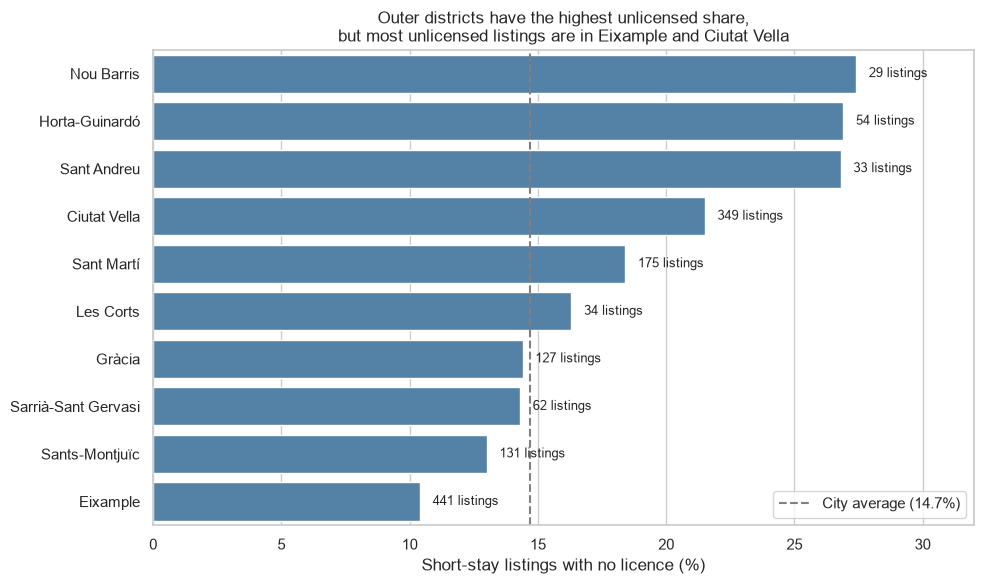

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=licence_by_district, x="pct_no_licence", y="district_name",
            color="steelblue", ax=ax)
ax.axvline(city_avg, color="grey", linestyle="--", label=f"City average ({city_avg}%)")

for i, row in licence_by_district.iterrows():
    ax.text(row["pct_no_licence"] + 0.5, i, f"{row['n_no_licence']} listings",
            va="center", fontsize=9)

ax.set(title="Outer districts have the highest unlicensed share,\n"
             "but most unlicensed listings are in Eixample and Ciutat Vella",
       xlabel="Short-stay listings with no licence (%)", ylabel="", xlim=(0, 32))
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Images/chart1_licence_by_district.png", dpi=150)
plt.show()

*Chart 1: Query 2. Bars show the share of each district's short-stay listings with no licence; labels show the number of listings. The dashed line is the city average from Query 1. Share and count point to different places: outer districts have the highest share, but Eixample and Ciutat Vella have the most unlicensed listings.*

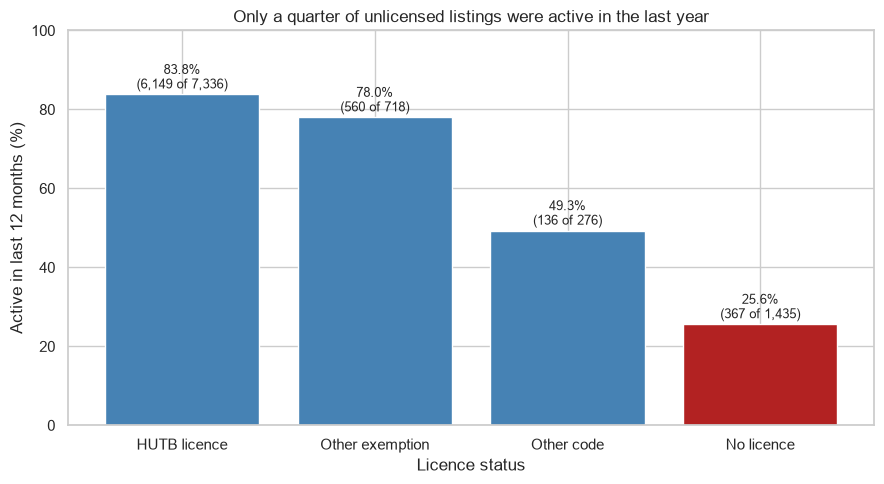

In [19]:
labels = {"hutb_licence": "HUTB licence", "exempt_other": "Other exemption",
          "other_code": "Other code", "missing": "No licence"}
activity["status_label"] = activity["status_code"].map(labels)

colors = ["firebrick" if status == "missing" else "steelblue" for status in activity["status_code"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(activity["status_label"], activity["pct_active"], color=colors)

for i, row in activity.iterrows():
    ax.text(i, row["pct_active"] + 1.5,
            f"{row['pct_active']}%\n({row['n_active']:,} of {row['n_short_stay']:,})",
            ha="center", fontsize=9)

ax.set(title="Only a quarter of unlicensed listings were active in the last year",
       xlabel="Licence status", ylabel="Active in last 12 months (%)", ylim=(0, 100))
plt.tight_layout()
plt.savefig("../Images/chart2_activity_by_licence.png", dpi=150)
plt.show()

*Chart 2: Query 4. "Active" means at least one review between 24 June 2025 and 24 June 2026; labels show the active listings out of the total in each status. Because a listing can be rented without being reviewed, these percentages are minimums, but the gap between licensed (83.8%) and unlicensed listings (25.6%) is too large to be explained by that alone.*

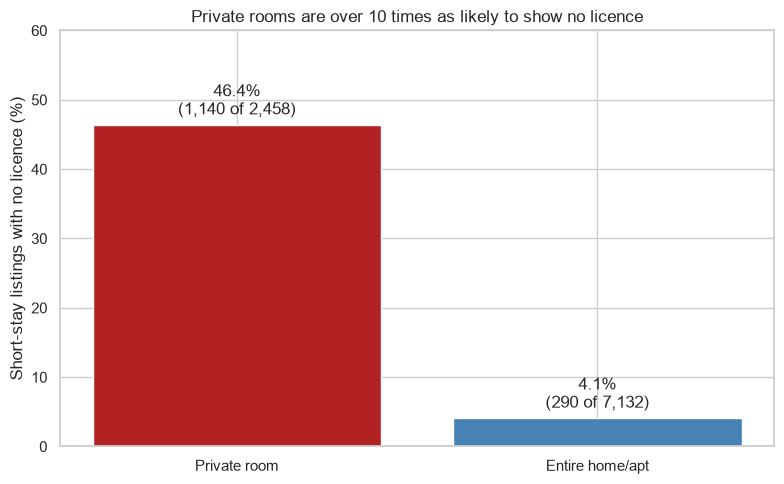

In [20]:
by_room = pd.read_sql(queries["q3"], con)
by_room = by_room[by_room["room_type"].isin(["Private room", "Entire home/apt"])]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(by_room["room_type"], by_room["pct_no_licence"], color=["firebrick", "steelblue"])

for i, row in enumerate(by_room.itertuples()):
    ax.text(i, row.pct_no_licence + 1.5,
            f"{row.pct_no_licence}%\n({row.n_no_licence:,} of {row.n_short_stay:,})", ha="center")

ax.set(title="Private rooms are over 10 times as likely to show no licence",
       xlabel="", ylabel="Short-stay listings with no licence (%)", ylim=(0, 60))
plt.tight_layout()
plt.savefig("../Images/chart5_licence_by_room_type.png", dpi=150)
plt.show()

Chart 3: Query 3. Shared rooms (107) and hotel rooms (68) are left out because they are too few to compare."

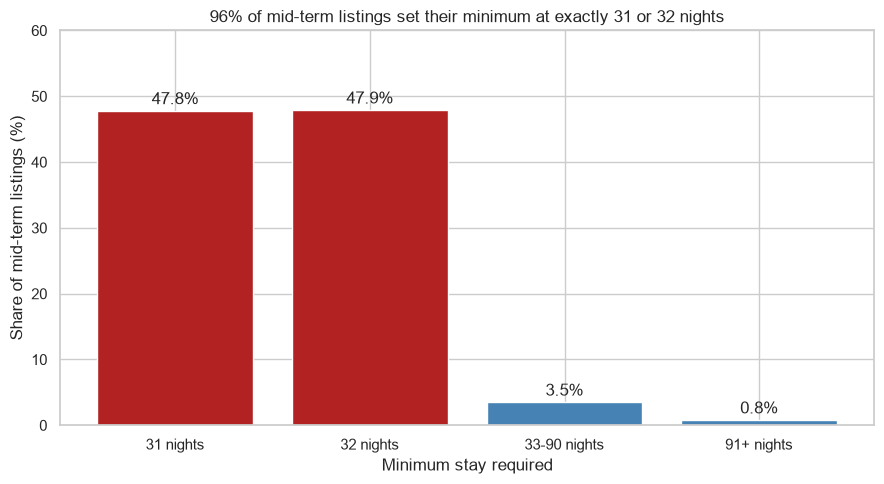

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["firebrick", "firebrick", "steelblue", "steelblue"]
ax.bar(min_stay["min_stay_band"], min_stay["pct_of_mid_term"], color=colors)

for i, row in min_stay.iterrows():
    ax.text(i, row["pct_of_mid_term"] + 1, f"{row['pct_of_mid_term']}%", ha="center")

ax.set(title="96% of mid-term listings set their minimum at exactly 31 or 32 nights",
       xlabel="Minimum stay required", ylabel="Share of mid-term listings (%)", ylim=(0, 60))
plt.tight_layout()
plt.savefig("../Images/chart3_min_stay_bands.png", dpi=150)
plt.show()

*Chart 4: Query 6b. Only listings requiring 31 nights or more are included (5,527). Almost all of them set the minimum one or two nights above the 31-night threshold of the tourist-licence rules; only 4.3% ask for more than 32 nights.*

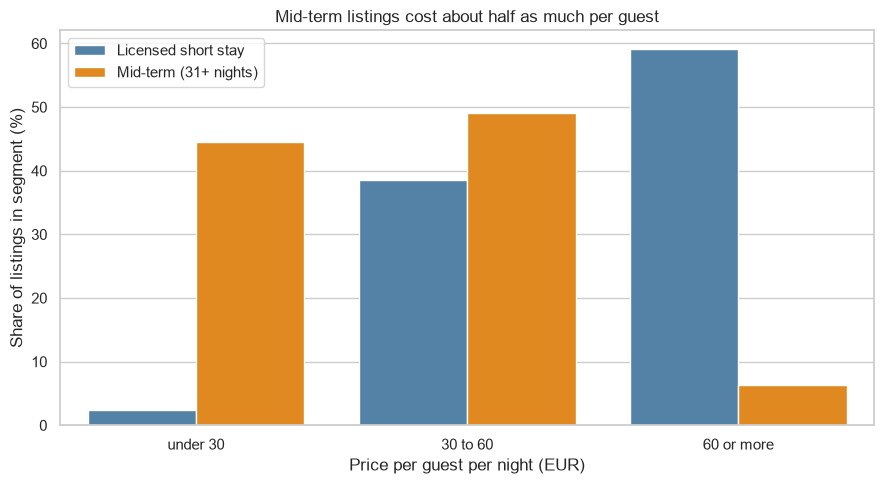

In [22]:
price_bands["Licensed short stay"] = (100 * price_bands["n_licensed_short_stay"]
                                      / price_bands["n_licensed_short_stay"].sum())
price_bands["Mid-term (31+ nights)"] = (100 * price_bands["n_mid_term"]
                                        / price_bands["n_mid_term"].sum())

price_bands_long = price_bands.melt(
    id_vars="price_per_guest_band",
    value_vars=["Licensed short stay", "Mid-term (31+ nights)"],
    var_name="segment", value_name="pct",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=price_bands_long, x="price_per_guest_band", y="pct", hue="segment",
            palette=["steelblue", "darkorange"], ax=ax)
ax.set(title="Mid-term listings cost about half as much per guest",
       xlabel="Price per guest per night (EUR)", ylabel="Share of listings in segment (%)")
ax.legend(title="")
plt.tight_layout()
plt.savefig("../Images/chart4_price_per_guest.png", dpi=150)
plt.show()

*Chart 5: Query 8b. Price per guest = nightly price divided by the number of guests the listing sleeps; listings without a price are excluded. Bars show the share of each segment in each price band, so the two segments are comparable despite their different sizes. The €30 and €60 thresholds were chosen to split the two segments' typical values and are not an industry standard.*

---
## 5. Conclusions

Answer each question. Say whether your hypothesis held. Being wrong is a fine result, as long as you say so and show the evidence.

### Q1: Licence compliance

**Answer:** 14.7% of short-stay listings (1,435) show no licence. They are overwhelmingly private rooms, and three in four of them were not active in the last year. In addition, almost a quarter of the listings that *do* show a licence number share it with another listing.

| Part of the hypothesis | Verdict | Evidence |
|---|---|---|
| Unlicensed listings are concentrated in private rooms | **Supported** | 46.4% of short-stay private rooms show no licence, against 4.1% of entire homes; private rooms are 79.4% of all unlicensed listings (Query 3) |
| They are concentrated in outer districts rather than the centre | **Partly supported** | The highest *shares* are in outer districts (~27%), but Ciutat Vella is also above average (21.5%), and Eixample and Ciutat Vella have the most unlicensed listings (441 and 349) (Query 2) |
| Most of them are inactive | **Supported** | Only 25.6% were active in the last year, against 83.8% of licensed listings (Query 4) |
| *Not hypothesised:* licence numbers are reliable | **Not supported** | 23.5% of listings showing a HUTB number share it; some numbers are clearly invented (Query 5) |

**What it means for the city council:** the headline figure overstates the problem. Only 367 unlicensed listings were active, about 5% of active short-stay supply. Most of the gap is private rooms, which the HUTB licence does not cover, so it looks structural rather than hidden. Inspections focused on counts would target Eixample and Ciutat Vella; inspections focused on rates would target the outer districts. Shared and invented licence numbers suggest that checking numbers, not just their presence, would catch a problem the "missing licence" count misses.

### Q2: The mid-term segment

**Answer:** the mid-term segment is large (36.1% of all listings), almost entirely set at 31 or 32 nights, located in the same central districts as licensed short stays, and about half the price per guest.

| Part of the hypothesis | Verdict | Evidence |
|---|---|---|
| The segment sits in the same central districts as licensed short stays | **Supported, with a split** | Ciutat Vella and Eixample hold 58.4% of mid-term listings and 59.7% of licensed short stays; but half of Ciutat Vella's listings are mid-term, while Eixample remains mainly licensed short-stay (Query 7) |
| It is cheaper per guest | **Supported** | €35.7 vs €73.9 on average; medians (€31.8 vs €65.6) and price bands agree (Query 8) |
| It is less active | **Not settled** | 44.6% vs 83.8% active, but activity is measured through reviews, and longer stays generate fewer reviews by nature, so the data cannot separate a real difference from the measurement (Query 8) |
| It partly absorbs supply that cannot get a tourist licence | **Consistent with the data, not proven** | 95.7% of mid-term listings set the minimum at exactly 31 or 32 nights (Query 6), which points to the rule shaping the offer; but the lower prices and Sarrià-Sant Gervasi's high mid-term share (51.0%) also fit a genuine long-stay market |

**What it means for policy makers:** one in three Barcelona listings sits just outside the tourist-licence regime, in the same central areas. Whether that is a loophole or a legitimate housing product cannot be decided from listing data alone, but the clustering at 31–32 nights shows the 31-day threshold is shaping the market, so any change to that threshold would affect a third of supply.

### Overall

Both questions point to the same conclusion: **Barcelona's Airbnb market is organised around its rules.** The licence system leaves private rooms uncovered, and the 31-day threshold has produced a large segment positioned exactly one or two nights above it. The data is strong on *what* the market looks like and much weaker on *why*, which is the subject of the next section.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.

### Limitations

| Limitation | Affects | Effect on the conclusions |
|---|---|---|
| **The licence field is self-declared text**, not checked against the official register | Queries 1–5 | "No licence shown" is not the same as "no licence", and a number shown is not proof it is valid. The 14.7% unlicensed figure could be too high (hosts who have a licence but did not display it) and the 75.1% licensed figure too high (invalid numbers, Query 5) |
| **Activity is measured through reviews** | Queries 4 and 8 | A listing can be rented without being reviewed, so all "active" shares are minimums. The bias is stronger for mid-term listings, whose long stays generate fewer reviews, which is why "less active" is *not settled* |
| **One snapshot only** | All, especially Q2 | The data shows the market on one day. It cannot show whether the mid-term segment grew after a rule changed, which is what would show *why* hosts choose 31 nights |
| **A listing is not a dwelling** | Queries 1–5 | One flat can appear as several listings, and one listing can be removed and re-created. Some of the shared licence numbers may be legitimate for this reason |
| **Prices are asking prices**, missing for 12.7% of listings | Query 8 | They show what hosts ask, not what guests pay or how often. Listings without a price (mostly not live on the snapshot date) are excluded from the price comparison |
| **Price per guest assumes full capacity** | Query 8 | A flat for 4 rented to 2 people costs more per guest than the figure suggests. The comparison holds between segments, but the euro values are indicative |
| **Airbnb only** | All | Hosts can also advertise on other platforms. Unlicensed supply could be larger or smaller elsewhere |
| **Descriptive analysis only** | All | Differences are large, but no statistical test was run, so the verdicts rest on the size of the gaps rather than on significance |

None of these reverses a finding: the gaps between groups (46.4% vs 4.1%, 25.6% vs 83.8%, 95.7% at 31–32 nights) are far larger than any of these effects is likely to be. They do mean the exact percentages should be read as estimates.

### Next steps (with another week)

1. **Check licence numbers against the official register.** Catalonia publishes its tourism register; matching numbers against it would turn "shows a number" into "has a valid licence", and settle how many shared numbers are invalid.
2. **Compare several snapshots over time.** Inside Airbnb archives earlier quarters for Barcelona. Tracking the share of 31+ night listings across rule changes would test the "why" behind Q2 that one snapshot cannot.
3. **Use the calendar file instead of reviews to measure activity.** Inside Airbnb also publishes each listing's day-by-day availability, a measure of activity that does not depend on guests leaving reviews, and would fix the bias that left "less active" unsettled.
4. **Read the review text of mid-term listings.** The `comments` column was left out of this project. Searching it for signs of long stays (students, work, "a month") would show whether mid-term guests are long-stay residents or tourists.
5. **Add statistical tests** (Week 4): a chi-square test and Cramér's V for room type vs licence status, and a test of the difference in price per guest between segments, to put a confidence level on the verdicts.

In [23]:
con.close()